In [90]:
from sklearn.tree import DecisionTreeClassifier
from lightgbm import LGBMClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
from scipy.stats import zscore
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt, seaborn as sns

In [91]:
test = pd.read_csv("test.csv")
train = pd.read_csv("train.csv")
sample_data = pd.read_csv("sample_submition.csv")

In [92]:
train['ts_transaction_time'] = pd.to_datetime(train['transaction_time']).values.astype('int64') // 10**9
test['ts_transaction_time'] = pd.to_datetime(test['transaction_time']).values.astype('int64') // 10**9

numeric_features = [
    'amount', 'ts_transaction_time', 'lat', 'lon', 'population_city', 'merchant_lat', 'merchant_lon'
]

cat_columns = [
    'merch', 'cat_id', 'name_1', 'name_2', 'gender', 'street', 'one_city', 'us_state', 'post_code', 'jobs'
]

## Выбросы

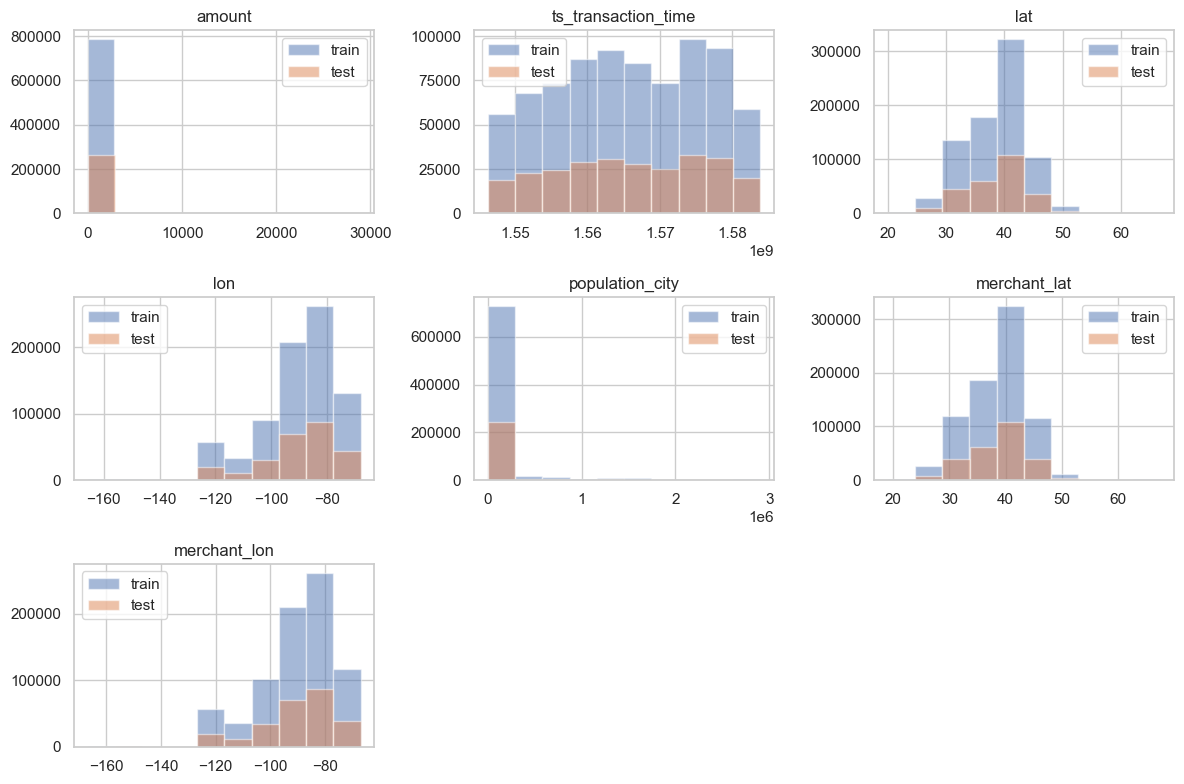

In [93]:
plt.figure(figsize=(12, 8))
for i, one_feature in enumerate(numeric_features):
    plt.subplot(3, 3, i+1)
    plt.hist(train[one_feature], alpha=0.5, label='train')
    plt.hist(test[one_feature], alpha=0.5, label='test')
    plt.legend()
    plt.title(one_feature)
plt.tight_layout()
plt.show()

amount train 7614 test 2694
ts_transaction_time train 0 test 0
lat train 2804 test 940
lon train 2804 test 940
population_city train 20039 test 6572
merchant_lat train 2804 test 940
merchant_lon train 2804 test 940


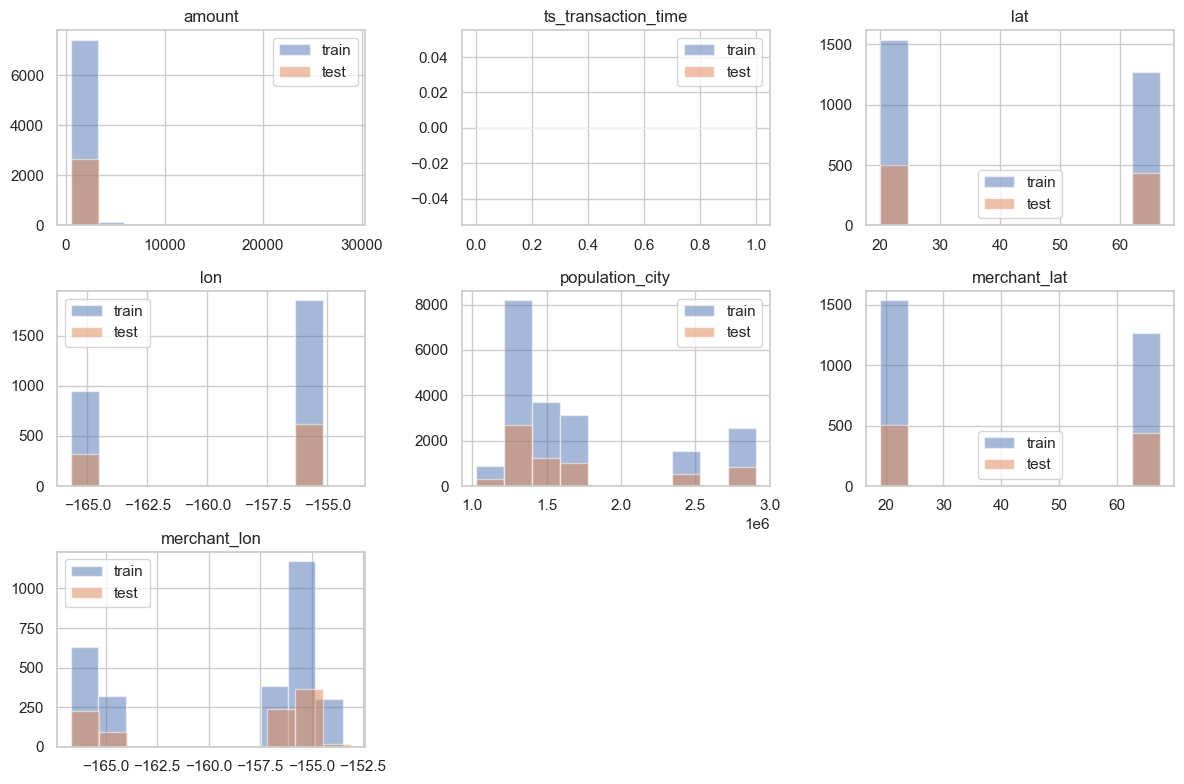

In [94]:
plt.figure(figsize=(12, 8))
for i, one_feature in enumerate(numeric_features):
  plt.subplot(3, 3, i+1)

  mask_outliesr_train = np.abs(zscore(train[one_feature].values)) >= 3
  mask_outliesr_test = np.abs(zscore(test[one_feature].values)) >= 3

  print(
      one_feature,
      'train', sum(mask_outliesr_train),
      'test', sum(mask_outliesr_test),
  )

  plt.hist(train[mask_outliesr_train][one_feature], alpha=0.5, label='train')
  plt.hist(test[mask_outliesr_test][one_feature], alpha=0.5, label='test')
  plt.legend()
  plt.title(one_feature)
plt.tight_layout()
plt.show()

In [95]:
c = 0
for one_feature in cat_columns:
  print(one_feature, train[one_feature].nunique())
  c += train[one_feature].nunique()

merch 693
cat_id 14
name_1 348
name_2 479
gender 2
street 965
one_city 879
us_state 51
post_code 952
jobs 493


In [96]:
c_1 = 0
for one_feature in cat_columns:
  print(one_feature, test[one_feature].nunique())
  c_1 += test[one_feature].nunique()

merch 693
cat_id 14
name_1 347
name_2 478
gender 2
street 960
one_city 876
us_state 51
post_code 947
jobs 492


## Фтючинг энжениринг

In [97]:
import category_encoders as ce

target_enc = ce.CatBoostEncoder(cols=cat_columns)
target_enc = target_enc.fit(train[cat_columns], train['target'])

train = train.join(target_enc.transform(train[cat_columns]).add_suffix('_cb'))
test = test.join(target_enc.transform(test[cat_columns]).add_suffix('_cb'))



In [98]:
import numpy as np
from math import atan2, cos, radians, sin, sqrt


def haversine_distance(lat1: float, lon1: float, lat2: float, lon2: float, n_digits: int = 0) -> float:
    """
        Функция для расчёта расстояния от точки А до Б по прямой

        :param lat1: Широта точки А
        :param lon1: Долгота точки А
        :param lat2: Широта точки Б
        :param lon2: Долгота точки Б
        :param n_digits: Округляем полученный ответ до n знака после запятой
        :return: Дистанция по прямой с точностью до n_digits
    """

    lat1, lon1, lat2, lon2 = round(lat1, 6), round(lon1, 6), round(lat2, 6), round(lon2, 6)
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    dphi = np.radians(lat2 - lat1)

    dlambda = np.radians(lon2 - lon1)
    a = np.sin(dphi / 2) ** 2 + np.cos(phi1) * np.cos(phi2) * np.sin(dlambda / 2) ** 2

    return round(2 * 6372800 * np.arctan2(np.sqrt(a), np.sqrt(1 - a)), n_digits)  # метры.сантиметры


def bearing_degree(lat1: float, lon1: float, lat2: float, lon2: float, n_digits: int = 0) -> float:
    """
        Функция для расчёта угла между прямой [((lat1, lon1), (lat2, lon2)), (нулевой мередиан)]

        :param lat1: Широта точки А
        :param lon1: Долгота точки А
        :param lat2: Широта точки Б
        :param lon2: Долгота точки Б
        :param n_digits: Округляем полученный ответ до n знака после запятой
        :return: Значение угла с точностью до n_digits
    """

    lat1, lon1 = np.radians(round(lat1, 6)), np.radians(round(lon1, 6))
    lat2, lon2 = np.radians(round(lat2, 6)), np.radians(round(lon2, 6))

    dlon = (lon2 - lon1)
    numerator = np.sin(dlon) * np.cos(lat2)
    denominator = np.cos(lat1) * np.sin(lat2) - (np.sin(lat1) * np.cos(lat2) * np.cos(dlon))

    theta = np.arctan2(numerator, denominator)
    theta_deg = (np.degrees(theta) + 360) % 360

    return round(theta_deg, n_digits)

In [99]:
train['bearing_degree_1'] = bearing_degree(train['lat'], train['lon'], train['merchant_lat'], train['merchant_lon'], ).values
test['bearing_degree_1'] = bearing_degree(test['lat'], test['lon'], test['merchant_lat'], test['merchant_lon'], ).values

train['bearing_degree_2'] = bearing_degree(train['lat'], train['lon'], 0, 0, ).values
test['bearing_degree_2'] = bearing_degree(test['lat'], test['lon'], 0, 0, ).values

train['bearing_degree_3'] = bearing_degree(0, 0, train['merchant_lat'], train['merchant_lon'], ).values
test['bearing_degree_3'] = bearing_degree(0, 0, test['merchant_lat'], test['merchant_lon'], ).values

In [100]:
train['hav_dist_1'] = haversine_distance(train['lat'], train['lon'], train['merchant_lat'], train['merchant_lon'], ).values
test['hav_dist_1'] = haversine_distance(test['lat'], test['lon'], test['merchant_lat'], test['merchant_lon'], ).values

train['hav_dist_2'] = haversine_distance(train['lat'], train['lon'], 0, 0, ).values
test['hav_dist_2'] = haversine_distance(test['lat'], test['lon'], 0, 0, ).values

train['hav_dist_3'] = haversine_distance(0, 0, train['merchant_lat'], train['merchant_lon'], ).values
test['hav_dist_3'] = haversine_distance(0, 0, test['merchant_lat'], test['merchant_lon'], ).values

## Baseline model

In [101]:
model_features = [
  'amount',
  'bearing_degree_1',
  'bearing_degree_2',
  'bearing_degree_3',
  'cat_id_cb',
  'gender_cb',
  'hav_dist_1',
  'hav_dist_2',
  'hav_dist_3',
  'jobs_cb',
  'lat',
  'lon',
  'merch_cb',
  'merchant_lat',
  'merchant_lon',
  'name_1_cb',
  'name_2_cb',
  'one_city_cb',
  'population_city',
  'post_code_cb',
  'street_cb',
  'us_state_cb',
]

In [102]:
model = LGBMClassifier(n_estimators=50, random_state=14, )

In [103]:
X_train, X_test, y_train, y_test = train_test_split(
    train[model_features], train['target'], test_size=0.25, random_state=42,
    stratify=train['target']
)

In [104]:
%%time
model = model.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 3378, number of negative: 586445
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.017216 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4459
[LightGBM] [Info] Number of data points in the train set: 589823, number of used features: 22
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.005727 -> initscore=-5.156795
[LightGBM] [Info] Start training from score -5.156795
CPU times: total: 6.11 s
Wall time: 566 ms


In [105]:
predictions = model.predict_proba(X_test)

predictions = predictions[:, 1]

In [106]:
from sklearn.metrics import precision_recall_curve, f1_score


def plot_precision_recall_f1_vs_threshold(y_true, y_scores, with_graf = True):
    """
    Визуализирует precision, recall и F1-score в зависимости от порога (threshold)
    для задачи бинарной классификации.

    Параметры:
    ----------
    y_true : array-like
        Истинные метки классов
    y_scores : array-like
        Вероятности принадлежности к положительному классу
    with_graf : bool

    """
    # Вычисляем precision, recall и thresholds
    precisions, recalls, thresholds = precision_recall_curve(y_true, y_scores)

    # Вычисляем F1 score для каждого порога
    f1_scores = []
    for threshold in thresholds:
        y_pred = (y_scores >= threshold).astype(int)
        f1 = f1_score(y_true, y_pred)
        f1_scores.append(f1)

    # Находим оптимальный порог для максимального F1
    best_threshold_idx = np.argmax(f1_scores)
    best_threshold = thresholds[best_threshold_idx]
    best_f1 = f1_scores[best_threshold_idx]

    if with_graf:
        # Создаем график
        plt.figure(figsize=(6, 4))

        # Строим кривые precision и recall
        plt.plot(thresholds, precisions[:-1], "b-", linewidth=2, label="Precision")
        plt.plot(thresholds, recalls[:-1], "g-", linewidth=2, label="Recall")
        plt.plot(thresholds, f1_scores, "r-", linewidth=2, label="F1 Score")

        # Отмечаем точку с оптимальным порогом
        plt.plot([best_threshold], [best_f1], 'ro', markersize=8,
                label=f'Best threshold = {best_threshold:.2f}, F1 = {best_f1:.2f}')
        plt.axvline(x=best_threshold, color='r', linestyle='--')

        # Добавляем стандартный порог 0.5 для сравнения
        default_threshold = 0.5
        default_idx = np.abs(thresholds - default_threshold).argmin()
        default_f1 = f1_scores[default_idx]
        plt.axvline(x=default_threshold, color='k', linestyle='--',
                    label=f'Default threshold = 0.5, F1 = {default_f1:.2f}')

        # Настраиваем график
        plt.xlabel("Threshold", fontsize=12)
        plt.ylabel("Score", fontsize=12)
        plt.title("Precision, Recall, and F1 Score vs Threshold", fontsize=14)
        plt.legend(loc="best", fontsize=10)
        plt.grid(True, linestyle='--', alpha=0.7)
        plt.xlim([0, 1])
        plt.ylim([0, 1.05])

        # Добавляем аннотацию с информацией о лучшем пороге
        plt.annotate(f'Best F1: {best_f1:.2f} at threshold: {best_threshold:.2f}',
                    xy=(best_threshold, best_f1), xytext=(best_threshold+0.1, best_f1-0.1),
                    arrowprops=dict(facecolor='black', shrink=0.05, width=1.5, headwidth=7),
                    fontsize=10, bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="black", lw=1))

        plt.tight_layout()
        plt.show()

    # Возвращаем оптимальный порог и соответствующее значение F1
    return best_threshold, best_f1

In [107]:
# TODO: подобрать threshold модели (поменять np.mean(predictions))
predictions_binary = predictions >= np.mean(predictions)

In [108]:
f1_score(y_test, predictions_binary)

0.3692127368626685

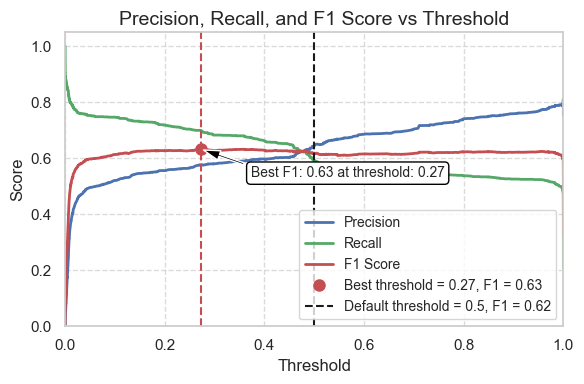

In [109]:
best_threshold, best_f1 = plot_precision_recall_f1_vs_threshold(y_test, predictions)

In [110]:
import pandas as pd
import numpy as np
from sklearn.model_selection import KFold
from sklearn.metrics import f1_score, confusion_matrix, classification_report
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier

def cross_validation_with_classification(
    X_train, y_train, X_test, y_test,
    model=None, n_folds=5, random_state=42, average='weighted'
):
    """
    Функция для проведения кросс-валидации с отслеживанием F1-метрики и визуализацией результатов классификации

    Параметры:
    X_train - признаки обучающей выборки (pandas DataFrame)
    y_train - целевая переменная обучающей выборки (pandas Series или numpy array)
    X_test - признаки тестовой выборки (pandas DataFrame)
    y_test - целевая переменная тестовой выборки (pandas Series или numpy array)
    model - модель машинного обучения (по умолчанию RandomForestClassifier)
    n_folds - количество фолдов для кросс-валидации
    random_state - фиксированное значение для воспроизводимости результатов
    average - метод усреднения для F1-метрики ('micro', 'macro', 'weighted', 'binary')

    Возвращает:
    cv_results - словарь с результатами кросс-валидации
    final_model - обученная модель на всех тренировочных данных
    """

    # Проверка входных данных
    if not isinstance(X_train, pd.DataFrame):
        raise TypeError("X_train должен быть pandas DataFrame")

    if not isinstance(X_test, pd.DataFrame):
        raise TypeError("X_test должен быть pandas DataFrame")

    # Проверка, что все наборы данных имеют одинаковые колонки
    if not set(X_train.columns) == set(X_test.columns):
        raise ValueError("Колонки в X_train и X_test должны совпадать")

    # Если модель не задана, используем RandomForestClassifier по умолчанию
    if model is None:
        model = RandomForestClassifier(n_estimators=100, random_state=random_state)

    # Инициализируем KFold для кросс-валидации
    kf = KFold(n_splits=n_folds, shuffle=True, random_state=random_state)

    # Словарь для хранения результатов
    cv_results = {
        'train_predictions': np.zeros(len(y_train)),
        'train_proba': np.zeros(len(y_train)),
        'train_actual': y_train,
        'test_predictions': None,
        'test_proba': None,
        'test_actual': y_test,
        'fold_f1': [],
        'train_f1': 0,
        'val_f1': 0,
        'test_f1': 0,
        'val_threshold': [],
        'train_threshold': [],
        'class_report': None
    }

    # Массивы для хранения метрик по фолдам
    fold_train_f1 = []
    fold_val_f1 = []

    print("Начинаем процесс кросс-валидации...")

    # Проходим по всем фолдам
    for fold, (train_idx, val_idx) in enumerate(tqdm(kf.split(X_train), total=n_folds, desc="Фолды")):
        # Разделяем данные на обучающую и валидационную выборки
        X_fold_train, X_fold_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_fold_train, y_fold_val = y_train.iloc[train_idx] if isinstance(y_train, pd.Series) else y_train[train_idx], \
                                  y_train.iloc[val_idx] if isinstance(y_train, pd.Series) else y_train[val_idx]

        # Обучаем модель
        model.fit(X_fold_train, y_fold_train)

        # Делаем предсказания на обучающей и валидационной выборках
        y_fold_train_pred = model.predict(X_fold_train)
        
        # Сохраняем вероятности (если есть метод predict_proba)
        
        y_fold_val_proba = model.predict_proba(X_fold_val)[:, 1]  # берем вероятности положительного класса
        cv_results['train_predictions'][val_idx] = y_fold_val_proba

        # Вычисляем F1 для этого фолда
        train_threshold, train_f1 = plot_precision_recall_f1_vs_threshold(y_fold_train, y_fold_train_pred, with_graf=False)
        val_threshold, val_f1 = plot_precision_recall_f1_vs_threshold(y_fold_val, y_fold_val_proba, with_graf=False)

        fold_train_f1.append(train_f1)
        fold_val_f1.append(val_f1)
        cv_results['fold_f1'].append(val_f1)
        cv_results['train_threshold'].append(train_threshold)
        cv_results['val_threshold'].append(val_threshold)

        print(f"Фолд {fold+1}/{n_folds}:")
        print(f"  F1 на обучающей выборке: {train_f1:.4f}")
        print(f"  F1 на валидационной выборке: {val_f1:.4f}")

    # Вычисляем средние значения F1
    cv_results['train_f1'] = np.mean(fold_train_f1)
    cv_results['val_f1'] = np.mean(fold_val_f1)

    print(f"\nСредняя F1 на обучающей выборке: {cv_results['train_f1']:.4f}")
    print(f"Средняя F1 на валидационной выборке: {cv_results['val_f1']:.4f}")

    # Обучаем финальную модель на всех тренировочных данных
    print("\nОбучаем финальную модель на всех тренировочных данных...")
    final_model = model.fit(X_train, y_train)

    # Делаем предсказания на тестовой выборке
    cv_results['test_predictions'] = final_model.predict(X_test)
    if hasattr(final_model, 'predict_proba'):
        cv_results['test_proba'] = final_model.predict_proba(X_test)[:, 1]

    # Вычисляем F1 на тестовой выборке
    test_threshold, cv_results['test_f1'] = plot_precision_recall_f1_vs_threshold(y_test, cv_results['test_predictions'])
    print(f"F1 на тестовой выборке: {cv_results['test_f1']:.4f}")

    # Генерируем отчет по классификации
    cv_results['class_report'] = classification_report(y_test, cv_results['test_predictions'])
    print("\nОтчет по классификации на тестовой выборке:")
    print(cv_results['class_report'])


    # Визуализация результатов
    visualize_classification_results(cv_results, n_folds, average)

    return cv_results, final_model

def visualize_classification_results(cv_results, n_folds, average):
    """
    Функция для визуализации результатов классификации

    Параметры:
    cv_results - словарь с результатами кросс-валидации
    n_folds - количество фолдов
    average - метод усреднения для F1-метрики
    """
    # Настраиваем стиль графиков
    sns.set(style="whitegrid")

    # 1. График F1 по фолдам
    plt.figure(figsize=(12, 8))

    plt.subplot(2, 2, 1)
    plt.bar(range(1, n_folds+1), cv_results['fold_f1'], color='skyblue')
    plt.axhline(y=np.mean(cv_results['fold_f1']), color='r', linestyle='-',
               label=f'Среднее: {np.mean(cv_results["fold_f1"]):.4f}')
    plt.title(f'F1 ({average}) по фолдам')
    plt.xlabel('Номер фолда')
    plt.ylabel('F1 score')
    plt.xticks(range(1, n_folds+1))
    plt.legend()
    plt.grid(True)

    # 2. Матрица ошибок для тестовой выборки
    plt.subplot(2, 2, 2)
    cm = confusion_matrix(cv_results['test_actual'], cv_results['test_predictions'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title('Матрица ошибок (Тестовая выборка)')
    plt.xlabel('Предсказанные классы')
    plt.ylabel('Истинные классы')

    # 3. Если есть вероятности, строим ROC-кривую (для бинарной классификации)
    if cv_results['test_proba'] is not None and len(np.unique(cv_results['test_actual'])) == 2:
        from sklearn.metrics import roc_curve, roc_auc_score
        fpr, tpr, thresholds = roc_curve(cv_results['test_actual'], cv_results['test_proba'])
        auc_score = roc_auc_score(cv_results['test_actual'], cv_results['test_proba'])
        
        plt.subplot(2, 2, 3)
        plt.plot(fpr, tpr, label=f'ROC кривая (AUC = {auc_score:.2f})')
        plt.plot([0, 1], [0, 1], 'k--')
        plt.xlim([0.0, 1.0])
        plt.ylim([0.0, 1.05])
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title('ROC кривая (Тестовая выборка)')
        plt.legend(loc="lower right")
        plt.grid(True)

    # 4. Сравнение F1 на разных наборах данных
    plt.subplot(2, 2, 4)

    # Собираем метрики для всех наборов данных
    datasets = ['Кросс-валидация', 'Тест']
    f1_values = [cv_results['val_f1'], cv_results['test_f1']]

    # if cv_results['oot_f1'] is not None:
    #     datasets.append('OOT')
    #     f1_values.append(cv_results['oot_f1'])

    plt.bar(datasets, f1_values, color='skyblue')
    plt.title(f'Сравнение F1 ({average}) на разных наборах данных')
    plt.ylabel('F1 score')
    plt.grid(True)

    # Добавляем значения F1 над столбцами
    for i, v in enumerate(f1_values):
        plt.text(i, v + 0.01, f'{v:.4f}', ha='center')

    plt.tight_layout()
    plt.show()

In [112]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

models = {
    'LGBMC': LGBMClassifier(n_estimators=40, random_state=14, ),
    'Random Forest': RandomForestClassifier(n_estimators=40, random_state=42,),
    'GradientBoosting': GradientBoostingClassifier(n_estimators=40),
    'xgb': XGBClassifier(n_estimators=40)
}

for name, model_one in models.items():
    cv_result, model = cross_validation_with_classification(X_train, y_train, X_test, y_test, model=model_one)


Начинаем процесс кросс-валидации...


Фолды:   0%|          | 0/5 [00:00<?, ?it/s]

[LightGBM] [Info] Number of positive: 2716, number of negative: 469142
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.011787 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4458
[LightGBM] [Info] Number of data points in the train set: 471858, number of used features: 22
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.005756 -> initscore=-5.151745
[LightGBM] [Info] Start training from score -5.151745


Фолды:  20%|██        | 1/5 [00:54<03:36, 54.05s/it]

Фолд 1/5:
  F1 на обучающей выборке: 0.7140
  F1 на валидационной выборке: 0.6612
[LightGBM] [Info] Number of positive: 2673, number of negative: 469185
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.013077 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4460
[LightGBM] [Info] Number of data points in the train set: 471858, number of used features: 22
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.005665 -> initscore=-5.167796
[LightGBM] [Info] Start training from score -5.167796


Фолды:  20%|██        | 1/5 [01:19<05:19, 79.94s/it]


KeyboardInterrupt: 

In [ ]:
import matplotlib.pyplot as plt

# Списки для хранения результатов
n_estimators_list = []
f1_scores_train = []
f1_scores_test = []

for n_e in range(5, 51, 5):
    model = RandomForestClassifier(n_estimators=n_e, random_state=42)  # Исправлено model_one на model
    model.fit(X_train, y_train)
    
    # Предсказания для тренировочных данных
    predict_y_train = model.predict_proba(X_train)[:, 1]
    best_threshold_train, f1_score_train_value = plot_precision_recall_f1_vs_threshold(y_train, predict_y_train, with_graf=False)
    f1_scores_train.append(f1_score_train_value)
    
    # Предсказания для тестовых данных
    predict_y_test = model.predict_proba(X_test)[:, 1]
    best_threshold, f1_score_test_value = plot_precision_recall_f1_vs_threshold(y_test, predict_y_test, with_graf=False)
    f1_scores_test.append(f1_score_test_value)
    
    n_estimators_list.append(n_e)
    
    print(f"n_estimators: {n_e}")
    print(f"Train best threshold: {best_threshold_train}, Train F1-score: {f1_score_train_value}")
    print(f"Test best threshold: {best_threshold}, Test F1-score: {f1_score_test_value}")
    print("-" * 50)

# Построение графика
plt.figure(figsize=(10, 6))
plt.plot(n_estimators_list, f1_scores_train, label='Train F1-score', marker='o')
plt.plot(n_estimators_list, f1_scores_test, label='Test F1-score', marker='o')
plt.xlabel('n_estimators')
plt.ylabel('F1-score')
plt.title('F1-score vs n_estimators')
plt.legend()
plt.grid(True)
plt.xticks(n_estimators_list)
plt.show()

TypeError: 'float' object is not callable

У нас тренировочная выборка обучается 99-100%, а тестовая не меняется, следовательно, у нас **переобучение**.

Попробуем выбрать гиперпараметры при которых не будет переобучения.

## Битва с переобучением с помощью гиперпараметров

In [113]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold

# Параметры для перебора
param_grid = {
    'n_estimators': [10, 20, 30, 40],
    'max_depth': [10, 20, None],
    'min_samples_split': [5, 10]
}

# Кросс-валидация с сохранением баланса классов
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Поиск по сетке
grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=cv,  # <- стратегия кросс-валидации
    scoring='f1',  # метрика оптимизации
    n_jobs=-1,  # параллельные вычисления
    verbose=1,
    return_train_score=True
)

grid_search.fit(X_train, y_train)

# Лучшие параметры
print("Лучшие параметры:", grid_search.best_params_)
print("Лучший F1-score:", grid_search.best_score_)

Fitting 5 folds for each of 24 candidates, totalling 120 fits


KeyboardInterrupt: 

In [ ]:
results = pd.DataFrame(grid_search.cv_results_)

sorted_results = results.sort_values('rank_test_score')[
    ['param_max_depth', 'param_min_samples_split', 'param_n_estimators',
      'mean_train_score', 'mean_test_score', 'std_test_score', 'rank_test_score']
]


# Выводим с переносами
with pd.option_context('display.max_colwidth', 100):
    display(sorted_results.head(10))

,param_max_depth,param_min_samples_split,param_n_estimators,mean_train_score,mean_test_score,std_test_score,rank_test_score
20,None,10,10,0.862804,0.707935,0.016397,1
21,None,10,20,0.864028,0.704373,0.012996,2
17,None,5,20,0.928947,0.702022,0.013412,3
22,None,10,30,0.863243,0.701576,0.011490,4
23,None,10,40,0.863048,0.700015,0.012441,5
19,None,5,40,0.928865,0.698933,0.012231,6
18,None,5,30,0.928853,0.696837,0.016562,7
16,None,5,10,0.916384,0.690380,0.015112,8
9,20,5,20,0.872299,0.689231,0.011341,9
8,20,5,10,0.865283,0.687783,0.007142,10


In [ ]:
results.columns

Index(['mean_fit_time', 'std_fit_time', 'mean_score_time', 'std_score_time',
       'param_max_depth', 'param_min_samples_split', 'param_n_estimators',
       'params', 'split0_test_score', 'split1_test_score', 'split2_test_score',
       'split3_test_score', 'split4_test_score', 'mean_test_score',
       'std_test_score', 'rank_test_score', 'split0_train_score',
       'split1_train_score', 'split2_train_score', 'split3_train_score',
       'split4_train_score', 'mean_train_score', 'std_train_score'],
      dtype='object')

In [ ]:
model = RandomForestClassifier(n_estimators=20, random_state=42)
model.fit(X_train, y_train)
predict_y = model.predict_proba(X_test)

predict_y = predict_y[:, 1]

best_threshold, f1_score = plot_precision_recall_f1_vs_threshold(y_test, predict_y)

print(f"best threshold: {best_threshold}")
print(f"f1-score: {f1_score}")

TypeError: 'float' object is not callable

In [ ]:
predict_y = grid_search.predict_proba(X_test)

predict_y = predict_y[:, 1]

best_threshold, f1_score = plot_precision_recall_f1_vs_threshold(y_test, predict_y)

print(f"best threshold: {best_threshold}")
print(f"f1-score: {f1_score}")

TypeError: 'float' object is not callable

In [ ]:
predictions = model.predict_proba(test[model_features])

predictions = predictions[:, 1]

predictions_binary = predictions >= best_threshold

In [ ]:
sample_data['prediction'] = predictions_binary

sample_data['prediction'] = sample_data['prediction'].astype(int)

sample_data.to_csv("sample_submition_1.csv", index=False)

## Мета модель

In [124]:
meta_features = np.zeros((test.shape[0], len(base_models)))
for i, (name, model) in enumerate(base_models):
    meta_features[:, i] = model.predict_proba(test[model_features])[:, 1]
    
meta_proba = meta_model.predict_proba(meta_features)[:, 1]
predictions_binary = meta_proba >= best_threshold
sample_data['prediction'] = predictions_binary

sample_data['prediction'] = sample_data['prediction'].astype(int)

sample_data.to_csv("sample_submition_1.csv", index=False)

Training RandomForest...


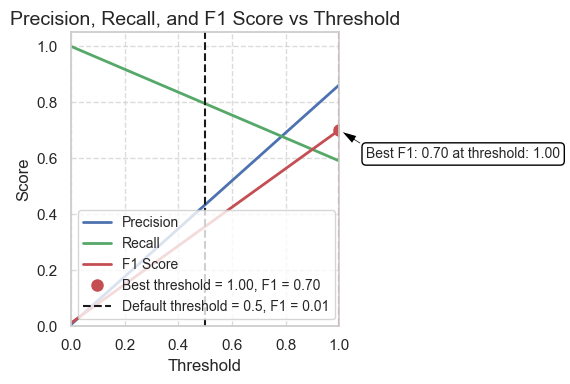

RandomForest - F1: 0.7011
------------------------------------------------------------
Training XGBoost...


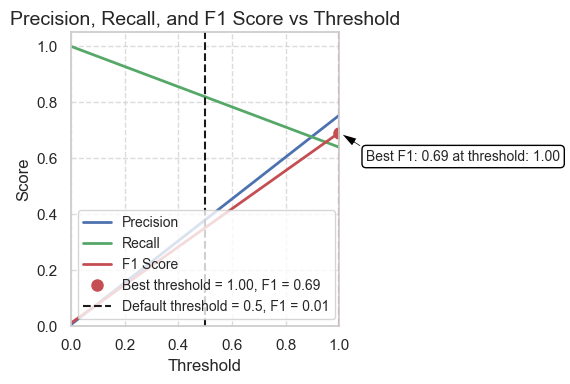

XGBoost - F1: 0.6920
------------------------------------------------------------
Training GradientBoosting...


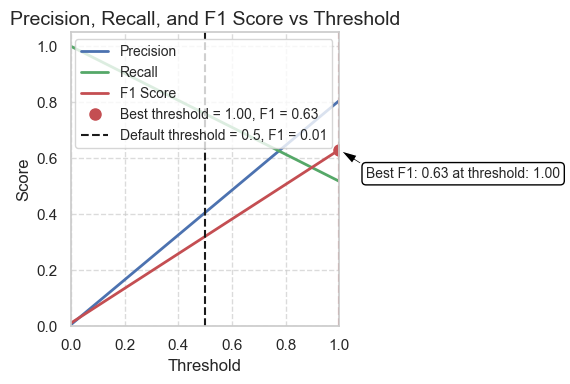

GradientBoosting - F1: 0.6306
------------------------------------------------------------


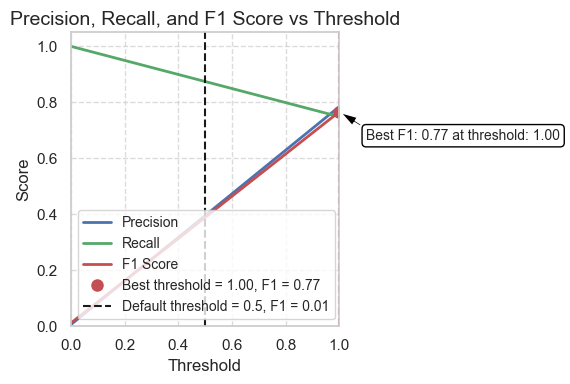


Meta-model performance:
F1-score: 0.7664

Average of base models:
F1-score: 0.7122


In [118]:
base_models = [
    ('RandomForest', RandomForestClassifier(n_estimators=20, random_state=42)),
    ('XGBoost', XGBClassifier(n_estimators=100, random_state=42)),
    ('GradientBoosting', GradientBoostingClassifier(n_estimators=40, random_state=42)),
]

# 3. Функция для обучения базовых моделей и сбора предсказаний
def train_base_models(models, X_train, y_train, X_test):
    meta_features_train = np.zeros((X_train.shape[0], len(models)))
    meta_features_test = np.zeros((X_test.shape[0], len(models)))
    
    for i, (name, model) in enumerate(models):
        print(f"Training {name}...")
        model.fit(X_train, y_train)
        
        # Получаем вероятности для положительного класса
        train_preds = model.predict_proba(X_train)[:, 1]
        test_preds = model.predict_proba(X_test)[:, 1]
        
        

        meta_features_train[:, i] = train_preds
        meta_features_test[:, i] = test_preds
        
        # Оцениваем качество по F1-score (основная метрика)
        y_pred = model.predict(X_test)
        best_threshold, f1 = plot_precision_recall_f1_vs_threshold(y_test, y_pred)
        print(f"{name} - F1: {f1:.4f}")
        print("-" * 60)
    
    return meta_features_train, meta_features_test

# Получаем мета-признаки
meta_train, meta_test = train_base_models(base_models, X_train, y_train, X_test)

# 4. Обучаем финальную мета-модель на предсказаниях
meta_model = LogisticRegression(random_state=42, class_weight='balanced')
meta_model.fit(meta_train, y_train)

# 5. Оцениваем качество мета-модели
meta_preds = meta_model.predict(meta_test)
best_threshold, f1 = plot_precision_recall_f1_vs_threshold(y_test, meta_preds)
meta_proba = meta_model.predict_proba(meta_test)[:, 1]


# meta_f1 = f1_score(y_test, meta_preds)

print("\nMeta-model performance:")
print(f"F1-score: {f1:.4f}")

# 6. Сравним с простым усреднением предсказаний
avg_proba = meta_test.mean(axis=1)
avg_preds = (avg_proba > 0.5).astype(int)
avg_f1 = f1_score(y_test, avg_preds)

print("\nAverage of base models:")
print(f"F1-score: {avg_f1:.4f}")

In [120]:
predictions_binary = meta_proba >= best_threshold
sample_data['prediction'] = predictions_binary

sample_data['prediction'] = sample_data['prediction'].astype(int)

sample_data.to_csv("sample_submition_1.csv", index=False)

ValueError: Length of values (196608) does not match length of index (262144)